# Statics -- F = m a with a = 0
### the two balance conditions, and why reaction forces are Lagrange multipliers

Statics is Newton's law with the acceleration set to zero -- nothing moves, so all the
forces and all the torques must cancel:
$$\sum \mathbf F = 0, \qquad \sum \tau = 0.$$
Those two equations solve every bracket, beam, truss, hinge, and bone for its unknown
**reaction forces**. And there is a beautiful tie to last notebook's Lagrangian: a
reaction force is exactly the **Lagrange multiplier** that enforces a "stays put"
constraint -- the multiplier *is* the force. Uses `dgs/statics.py`. Civilian
education / engineering.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import statics as st
print("ready")

ready


## 1. The lever -- torque balance and mechanical advantage

A seesaw balances when $F_1 d_1 = F_2 d_2$. A small force on a long arm holds a large
force on a short arm: the **mechanical advantage** $d_1/d_2$ behind every wrench,
crowbar, and muscle-and-bone joint.

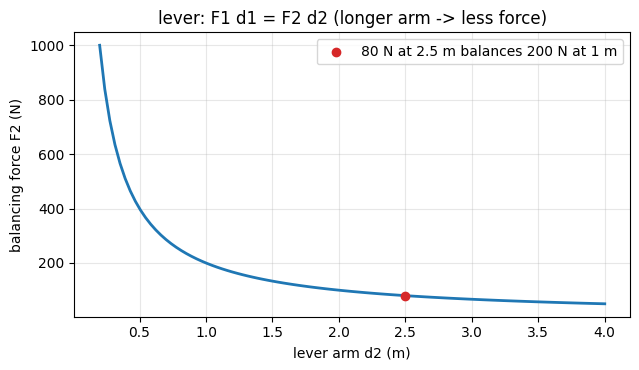

In [2]:
d2 = np.linspace(0.2, 4, 100); F1, d1 = 200.0, 1.0
F2 = st.lever(F1, d1, d2)                            # force needed at distance d2
plt.figure(figsize=(6.5,3.8))
plt.plot(d2, F2, lw=2)
plt.scatter([2.5], [st.lever(F1, d1, 2.5)], color="C3", zorder=5,
            label="80 N at 2.5 m balances 200 N at 1 m")
plt.xlabel("lever arm d2 (m)"); plt.ylabel("balancing force F2 (N)"); plt.legend()
plt.title("lever: F1 d1 = F2 d2 (longer arm -> less force)"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. The simply-supported beam -- a load shared by two supports

Put a load on a beam resting on two supports. Moment balance about one support fixes
the other reaction: a central load splits 50/50, and as the load slides toward a
support, that support takes more. The two reactions always sum to the load.

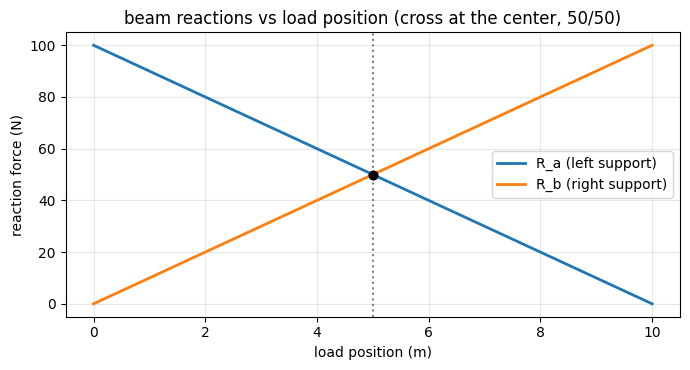

load at center -> (50, 50);  load at 8 m -> (20.0, 80.0)


In [3]:
L = 10.0; W = 100.0
xs = np.linspace(0, L, 100)
Ra = []; Rb = []
for x in xs:
    a, b = st.beam_reactions([(x, W)], 0.0, L); Ra.append(a); Rb.append(b)
plt.figure(figsize=(7,3.8))
plt.plot(xs, Ra, lw=2, label="R_a (left support)")
plt.plot(xs, Rb, lw=2, label="R_b (right support)")
plt.axvline(L/2, ls=":", color="gray"); plt.scatter([L/2,L/2],[W/2,W/2], color="k", zorder=5)
plt.xlabel("load position (m)"); plt.ylabel("reaction force (N)"); plt.legend()
plt.title("beam reactions vs load position (cross at the center, 50/50)"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("load at center -> (50, 50);  load at 8 m ->", st.beam_reactions([(8.0, W)], 0, L))

## 3. A worked bracket -- hinge + cable holding a weight

A horizontal beam is hinged at the wall and held level by a cable to its far end, with
a weight hung at the tip. Moments about the hinge give the cable tension
$T=W/\sin\theta$; force balance gives the hinge reaction. A shallow cable angle needs a
huge tension -- why support cables are steep.

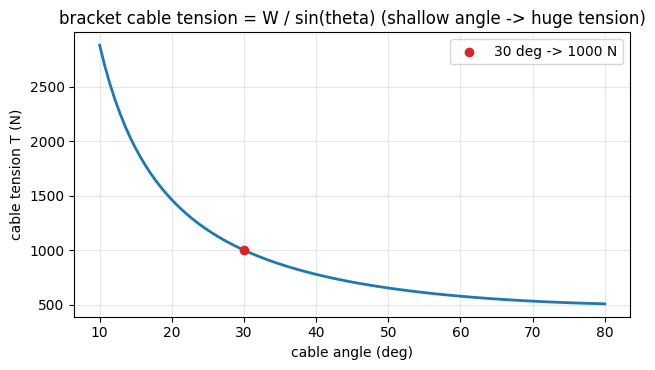

at 30 deg holding 500 N: tension 1000 N, hinge reaction (866, 0) N


In [4]:
angles = np.linspace(10, 80, 100)
T = [st.hinged_bracket(2.0, 500.0, a)[0] for a in angles]
plt.figure(figsize=(6.5,3.8))
plt.plot(angles, T, lw=2)
plt.scatter([30], [st.hinged_bracket(2.0,500.0,30)[0]], color="C3", zorder=5, label="30 deg -> 1000 N")
plt.xlabel("cable angle (deg)"); plt.ylabel("cable tension T (N)"); plt.legend()
plt.title("bracket cable tension = W / sin(theta) (shallow angle -> huge tension)")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
T, Hx, Hy = st.hinged_bracket(2.0, 500.0, 30.0)
print(f"at 30 deg holding 500 N: tension {T:.0f} N, hinge reaction ({Hx:.0f}, {Hy:.0f}) N")

## 4. Reaction forces ARE Lagrange multipliers

Hold a mass on a table: minimize the potential energy $V=mgy$ subject to the
constraint $y=0$ (the table). The Lagrange function is $V-\lambda y$, and stationarity
gives $\partial/\partial y:\ mg-\lambda=0$, so $\lambda=mg$ -- **the multiplier equals
the normal (reaction) force**. Every support reaction in statics is the multiplier of
its "stays put" constraint, the same machinery as `dgs.lagrangian`.

In [5]:
import sympy as sp
y, lam, m, g = sp.symbols("y lambda m g", real=True, positive=True)
Lstar = m*g*y - lam*y                                # V - lambda*(constraint y=0)
stat = sp.solve([sp.diff(Lstar, y)], [lam])          # d/dy = 0
print("constraint force lambda =", stat[lam], " = m g = the normal/reaction force")
print("=> the support reaction is exactly the Lagrange multiplier of 'stays on the table'")

constraint force lambda = g*m  = m g = the normal/reaction force
=> the support reaction is exactly the Lagrange multiplier of 'stays on the table'


## Takeaway

1. **Statics = F = m a with a = 0:** $\sum\mathbf F=0$ and $\sum\tau=0$, two
   conditions that solve for the unknown reactions.
2. The **lever** trades force for distance (mechanical advantage); a **beam** shares a
   load between supports by moment balance; a **bracket** sets cable tension by
   $W/\sin\theta$.
3. Each **reaction force is the Lagrange multiplier** of a geometric constraint -- the
   bridge from statics back to the Lagrangian.

When forces balance, the net torque is the same about every pivot -- which is why you
can take moments about whichever point kills the most unknowns. Civilian education.